# Uncertainty Quantification with Kernel Density Matrices (v2)

This notebook demonstrates how **KDMClassModel** naturally quantifies predictive
uncertainty through its probability-distribution outputs, and contrasts it with a
conventional **softmax classifier** (MLP baseline) built on the same CNN encoder.

**Experiment overview:**

1. We apply controlled rotations (0°–345° in 15° steps) to MNIST test images of digits
   **'1'**, **'6'**, and **'7'** and compare three uncertainty measures:
   **Shannon entropy**, **1 − MSP** (max softmax probability), and **−log P(x)**
   (KDM input log-likelihood).

2. For each measure we calibrate a detection threshold from the in-distribution test
   set (5% false-positive rate) and display it alongside the rotation curves.

3. We evaluate OOD detection performance quantitatively via ROC curves and AUROC,
   comparing all three KDM scores against the baseline's entropy and MSP.

PyTorch implementation of the example described in:
*Kernel Density Matrices for Probabilistic Deep Learning* (González et al., QMI 2025).

In [1]:
# Uncomment to install the required packages
# !pip install git+https://github.com/fagonzalezo/kdm.git

## 1. Imports and Setup

In [2]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF

from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib.lines import Line2D

from kdm.models import KDMClassModel
from kdm.init import init_kdm_layer
from kdm.utils import pure2dm

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Dataset Loading

We use a 20% subset of MNIST training data (~12 000 samples) for a quick demo.
Remove the index slice to use the full 60 000 samples for better accuracy.

In [3]:
mnist_train_full = datasets.MNIST(
    root='~/.cache/mnist', train=True, download=True,
    transform=transforms.ToTensor()
)
mnist_test_ds = datasets.MNIST(
    root='~/.cache/mnist', train=False, download=True,
    transform=transforms.ToTensor()
)

perm = np.random.RandomState(42).permutation(len(mnist_train_full))
# Uncoment the next line, and comment the 2nd next to train on a 20% subset
#train_idx = perm[:12000]
train_idx = perm

def stack(ds, idx):
    xs = torch.stack([ds[i][0] for i in idx])
    ys = torch.tensor([ds[i][1] for i in idx], dtype=torch.long)
    return xs, ys

X_train, y_train = stack(mnist_train_full, train_idx)
X_test  = torch.stack([mnist_test_ds[i][0] for i in range(len(mnist_test_ds))])
y_test  = torch.tensor([mnist_test_ds[i][1] for i in range(len(mnist_test_ds))],
                       dtype=torch.long)

print(f"train={X_train.shape}  test={X_test.shape}")

train=torch.Size([60000, 1, 28, 28])  test=torch.Size([10000, 1, 28, 28])


## 3. Model Architectures

Both models share the **same CNN encoder** architecture that maps 28×28 grayscale
images to a 32-dimensional latent vector. The only difference is the **output head**:

| Model | Head | Loss |
|---|---|---|
| Softmax baseline (MLP) | `Linear(32, 10)` | cross-entropy |
| KDMClassModel | `KDMLayer` + `dm2discrete` | NLL on KDM output |

Using the same encoder isolates the effect of the output head on uncertainty.

In [4]:
ENCODED_SIZE = 32
BASE_DEPTH   = 32
DIM_Y        = 10
BATCH_SIZE   = 128

# Softmax baseline
EPOCHS_BASE  = 50

# KDM 3-phase training
EPOCHS_WARM  = 1    # Phase 1: encoder warm-up
EPOCHS_DISC  = 5    # Phase 2: discriminative KDM
EPOCHS_GEN   = 50   # Phase 3: generative KDM
N_COMP_DISC  = 100  # KDM prototypes — Phase 2
N_COMP_GEN   = 200  # KDM prototypes — Phase 3 (more coverage for generative model)
ALPHA        = 1.0  # weight of the generative loss term

PATIENCE     = 5    # epochs without test-loss improvement before early stopping


def create_encoder(base_depth: int, encoded_size: int) -> nn.Module:
    """Small CNN: (bs,1,28,28) -> (bs, encoded_size)."""
    return nn.Sequential(
        nn.Conv2d(1, base_depth, 5, stride=1, padding=2),              nn.LeakyReLU(),
        nn.Conv2d(base_depth, base_depth, 5, stride=2, padding=2),     nn.LeakyReLU(),
        nn.Conv2d(base_depth, 2*base_depth, 5, stride=1, padding=2),   nn.LeakyReLU(),
        nn.Conv2d(2*base_depth, 2*base_depth, 5, stride=2, padding=2), nn.LeakyReLU(),
        nn.Conv2d(2*base_depth, 4*encoded_size, 7, stride=1, padding=0), nn.LeakyReLU(),
        nn.Flatten(),
        nn.Linear(4*encoded_size, encoded_size),
    )


class EarlyStopping:
    """Stops training when validation loss stops improving for `patience` epochs."""
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


@torch.no_grad()
def evaluate_base(model, X, y, batch_size=512):
    """Evaluate baseline (logit output) on tensors X, y."""
    model.eval()
    dev = next(model.parameters()).device
    total_loss, n_correct = 0.0, 0
    for i in range(0, len(X), batch_size):
        xb, yb = X[i:i+batch_size].to(dev), y[i:i+batch_size].to(dev)
        logits = model(xb)
        total_loss += F.cross_entropy(logits, yb).item() * xb.size(0)
        n_correct  += (logits.argmax(1) == yb).sum().item()
    return total_loss / len(X), n_correct / len(X)


@torch.no_grad()
def evaluate_kdm(model, X, y, batch_size=512):
    """Evaluate KDMClassModel (probability output) on tensors X, y."""
    model.eval()
    dev = next(model.parameters()).device
    total_loss, n_correct = 0.0, 0
    for i in range(0, len(X), batch_size):
        xb, yb = X[i:i+batch_size].to(dev), y[i:i+batch_size].to(dev)
        probs = model(xb)
        total_loss += F.nll_loss(torch.log(probs.clamp_min(1e-12)), yb).item() * xb.size(0)
        n_correct  += (probs.argmax(1) == yb).sum().item()
    return total_loss / len(X), n_correct / len(X)

## 4. Softmax Baseline

A conventional deep classifier: CNN encoder + linear head + softmax.

In [5]:
encoder_base   = create_encoder(BASE_DEPTH, ENCODED_SIZE)
baseline_model = nn.Sequential(encoder_base, nn.Linear(ENCODED_SIZE, DIM_Y)).to(device)

opt_base  = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)
loader    = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
hist_base = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
es_base   = EarlyStopping(patience=PATIENCE)

for ep in range(EPOCHS_BASE):
    baseline_model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = F.cross_entropy(baseline_model(xb), yb)
        opt_base.zero_grad(); loss.backward(); opt_base.step()
    tr_loss, tr_acc = evaluate_base(baseline_model, X_train, y_train)
    te_loss, te_acc = evaluate_base(baseline_model, X_test,  y_test)
    for k, v in [('train_loss', tr_loss), ('test_loss', te_loss),
                 ('train_acc',  tr_acc),  ('test_acc',  te_acc)]:
        hist_base[k].append(v)
    print(f"epoch {ep+1:2d}  train={tr_loss:.4f}/{tr_acc:.3f}  test={te_loss:.4f}/{te_acc:.3f}")
    if es_base.step(te_loss, baseline_model):
        print(f"  → early stopping (no improvement for {PATIENCE} epochs)")
        es_base.restore(baseline_model)
        break

epoch  1  train=0.0527/0.984  test=0.0496/0.985
epoch  2  train=0.0274/0.991  test=0.0327/0.990
epoch  3  train=0.0230/0.993  test=0.0407/0.988
epoch  4  train=0.0224/0.993  test=0.0410/0.986
epoch  5  train=0.0082/0.997  test=0.0295/0.991
epoch  6  train=0.0166/0.995  test=0.0416/0.989
epoch  7  train=0.0109/0.996  test=0.0350/0.990
epoch  8  train=0.0065/0.998  test=0.0379/0.991
epoch  9  train=0.0071/0.998  test=0.0298/0.992
epoch 10  train=0.0097/0.997  test=0.0365/0.989
  → early stopping (no improvement for 5 epochs)


## 5. KDM Classifier — 3-Phase Training

The KDM classifier is trained in three phases, mirroring the approach in the
classification-generation notebook. The KDM encoder is **independent of the softmax
baseline** — trained from scratch so any difference in behaviour reflects the
output head, not the encoder initialisation.

| Phase | What trains | Loss |
|---|---|---|
| **1 — Warm-up** | Encoder + linear head | Cross-entropy |
| **2 — Discriminative KDM** | Encoder + KDM layer (jointly) | NLL |
| **3 — Generative KDM** | KDM layer only (encoder frozen) | NLL + −α · log P(x) |

The encoder is frozen only in Phase 3, so the generative term does not distort the
discriminative representations learned in Phase 2. The Phase 3 model (`kdm_model`) is
used in all subsequent analysis.

In [6]:
# ── Phase 1: encoder warm-up ─────────────────────────────────────────────────
encoder_kdm = create_encoder(BASE_DEPTH, ENCODED_SIZE)
warm_head   = nn.Linear(ENCODED_SIZE, DIM_Y)
warm_model  = nn.Sequential(encoder_kdm, warm_head).to(device)
opt_warm    = torch.optim.Adam(warm_model.parameters(), lr=1e-3)
hist_kdm_warm = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for ep in range(EPOCHS_WARM):
    warm_model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = F.cross_entropy(warm_model(xb), yb)
        opt_warm.zero_grad(); loss.backward(); opt_warm.step()
    tr_loss, tr_acc = evaluate_base(warm_model, X_train, y_train)
    te_loss, te_acc = evaluate_base(warm_model, X_test,  y_test)
    for k, v in [('train_loss', tr_loss), ('test_loss', te_loss),
                 ('train_acc',  tr_acc),  ('test_acc',  te_acc)]:
        hist_kdm_warm[k].append(v)
    print(f"warm  epoch {ep+1:2d}  train={tr_loss:.4f}/{tr_acc:.3f}  test={te_loss:.4f}/{te_acc:.3f}")

# ── Phase 2: discriminative KDM (encoder + KDM trained jointly) ──────────────
kdm_disc = KDMClassModel(
    encoded_size=ENCODED_SIZE, dim_y=DIM_Y,
    encoder=encoder_kdm, n_comp=N_COMP_DISC, sigma=1.0, w_train=True,
).to(device)

idx = np.random.randint(X_train.shape[0], size=N_COMP_DISC)
encoder_kdm.eval()
with torch.no_grad():
    enc_x = encoder_kdm(X_train[idx].to(device))
init_kdm_layer(
    kdm_disc.kdm,
    encoded_x=enc_x,
    samples_y=F.one_hot(y_train[idx], DIM_Y).float().to(device),
    init_sigma=True,
)
print(f"Initial sigma (disc): {float(kdm_disc.kernel.sigma):.4f}")

opt_disc      = torch.optim.Adam(kdm_disc.parameters(), lr=1e-3)
hist_kdm_disc = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for ep in range(EPOCHS_DISC):
    kdm_disc.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        probs = kdm_disc(xb)
        loss  = F.nll_loss(torch.log(probs.clamp_min(1e-7)), yb)
        opt_disc.zero_grad(); loss.backward(); opt_disc.step()
    tr_loss, tr_acc = evaluate_kdm(kdm_disc, X_train, y_train)
    te_loss, te_acc = evaluate_kdm(kdm_disc, X_test,  y_test)
    for k, v in [('train_loss', tr_loss), ('test_loss', te_loss),
                 ('train_acc',  tr_acc),  ('test_acc',  te_acc)]:
        hist_kdm_disc[k].append(v)
    print(f"disc  epoch {ep+1:2d}  train={tr_loss:.4f}/{tr_acc:.3f}  "
          f"test={te_loss:.4f}/{te_acc:.3f}  sigma={float(kdm_disc.kernel.sigma):.4f}")

warm  epoch  1  train=0.0614/0.983  test=0.0601/0.981
Initial sigma (disc): 10.3017
disc  epoch  1  train=0.0367/0.989  test=0.0422/0.987  sigma=10.2669
disc  epoch  2  train=0.0226/0.993  test=0.0349/0.988  sigma=10.2345
disc  epoch  3  train=0.0183/0.995  test=0.0323/0.989  sigma=10.1849
disc  epoch  4  train=0.0102/0.997  test=0.0264/0.991  sigma=10.1299
disc  epoch  5  train=0.0077/0.998  test=0.0267/0.992  sigma=10.0808


In [7]:
# ── Phase 3: generative KDM ───────────────────────────────────────────────────
encoder_gen = copy.deepcopy(encoder_kdm)
for p in encoder_gen.parameters():
    p.requires_grad_(False)

kdm_model = KDMClassModel(
    encoded_size=ENCODED_SIZE, dim_y=DIM_Y,
    encoder=encoder_gen, n_comp=N_COMP_GEN, sigma=1.0, w_train=True,
).to(device)

idx = np.random.randint(X_train.shape[0], size=N_COMP_GEN)
encoder_gen.eval()
with torch.no_grad():
    enc_x_gen = encoder_gen(X_train[idx].to(device))
init_kdm_layer(
    kdm_model.kdm,
    encoded_x=enc_x_gen,
    samples_y=F.one_hot(y_train[idx], DIM_Y).float().to(device),
    init_sigma=False,
)
kdm_model.kernel.sigma = float(kdm_disc.kernel.sigma)
print(f"Initial sigma (gen): {float(kdm_model.kernel.sigma):.4f}")

opt_gen  = torch.optim.Adam(
    [p for p in kdm_model.parameters() if p.requires_grad], lr=1e-3
)
hist_kdm = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
es_gen   = EarlyStopping(patience=PATIENCE)

for ep in range(EPOCHS_GEN):
    kdm_model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        probs     = kdm_model(xb)
        disc_loss = F.nll_loss(torch.log(probs.clamp_min(1e-7)), yb)
        rho_x     = pure2dm(kdm_model.encoder(xb))
        gen_loss  = -ALPHA * kdm_model.kdm.log_marginal(rho_x).mean()
        loss      = disc_loss + gen_loss
        opt_gen.zero_grad(); loss.backward(); opt_gen.step()
    tr_loss, tr_acc = evaluate_kdm(kdm_model, X_train, y_train)
    te_loss, te_acc = evaluate_kdm(kdm_model, X_test,  y_test)
    for k, v in [('train_loss', tr_loss), ('test_loss', te_loss),
                 ('train_acc',  tr_acc),  ('test_acc',  te_acc)]:
        hist_kdm[k].append(v)
    print(f"gen   epoch {ep+1:2d}  train={tr_loss:.4f}/{tr_acc:.3f}  "
          f"test={te_loss:.4f}/{te_acc:.3f}  sigma={float(kdm_model.kernel.sigma):.4f}")
    if es_gen.step(te_loss, kdm_model):
        print(f"  → early stopping (no improvement for {PATIENCE} epochs)")
        es_gen.restore(kdm_model)
        break

Initial sigma (gen): 10.0808
gen   epoch  1  train=0.0098/0.997  test=0.0395/0.990  sigma=9.6076
gen   epoch  2  train=0.0083/0.998  test=0.0375/0.991  sigma=9.1257
gen   epoch  3  train=0.0097/0.997  test=0.0412/0.991  sigma=8.6365
gen   epoch  4  train=0.0091/0.997  test=0.0419/0.991  sigma=8.1414
gen   epoch  5  train=0.0100/0.997  test=0.0463/0.991  sigma=7.6411
gen   epoch  6  train=0.0096/0.997  test=0.0474/0.991  sigma=7.1362
gen   epoch  7  train=0.0105/0.997  test=0.0519/0.991  sigma=6.6280
  → early stopping (no improvement for 5 epochs)


## 6. Training Curves

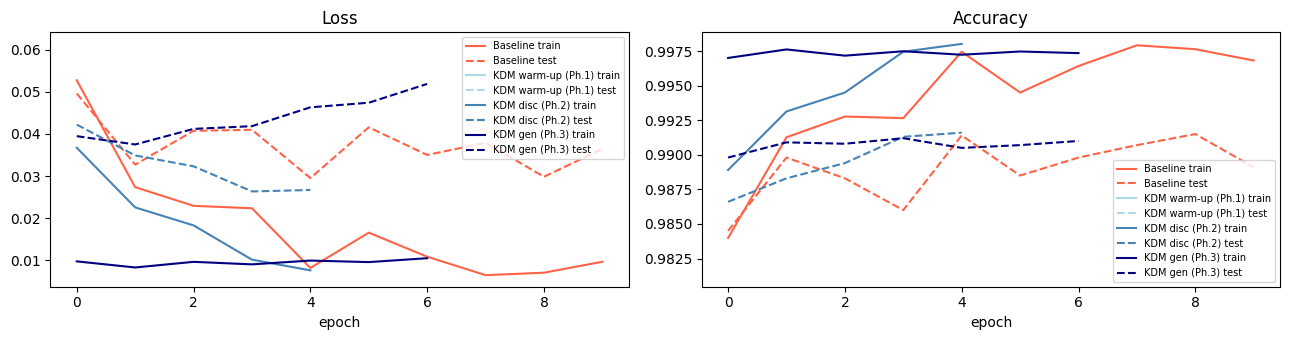

Baseline test accuracy : 0.9914
KDM gen  test accuracy : 0.9909


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

curves = [
    (hist_base,      'tomato',    'Baseline'),
    (hist_kdm_warm,  'lightblue', 'KDM warm-up (Ph.1)'),
    (hist_kdm_disc,  'steelblue', 'KDM disc (Ph.2)'),
    (hist_kdm,       'navy',      'KDM gen (Ph.3)'),
]

for h, color, label in curves:
    axes[0].plot(h['train_loss'], color=color, label=f'{label} train')
    axes[0].plot(h['test_loss'],  color=color, linestyle='--', label=f'{label} test')
    axes[1].plot(h['train_acc'],  color=color, label=f'{label} train')
    axes[1].plot(h['test_acc'],   color=color, linestyle='--', label=f'{label} test')

axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend(fontsize=7)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

_, base_te_acc = evaluate_base(baseline_model, X_test, y_test)
_, kdm_te_acc  = evaluate_kdm(kdm_model,       X_test, y_test)
print(f"Baseline test accuracy : {base_te_acc:.4f}")
print(f"KDM gen  test accuracy : {kdm_te_acc:.4f}")

## 7. Rotation Experiment Setup

We select one test image each of digits **'1'**, **'6'**, and **'7'** to probe three
qualitatively different uncertainty profiles under rotation:

- **'1'** is nearly rotationally symmetric. Geometric distortion is minimal across most
  angles, so uncertainty measures should remain relatively flat — providing a baseline
  for comparison.
- **'6'** is strongly asymmetric: near 180° it resembles a **'9'**, producing a sharp
  semantic transition. Both label-level and input-level uncertainty should spike
  together in this region.
- **'7'** is moderately asymmetric. Its slanted stroke means that some rotations push
  it toward classes such as '1' or '4', offering a third behavioural profile between
  the extremes of '1' and '6'.

For each digit we generate 24 rotated copies (0°, 15°, …, 345°) using
`torchvision.transforms.functional.rotate` with bilinear interpolation and
zero-padding (matching the MNIST background).

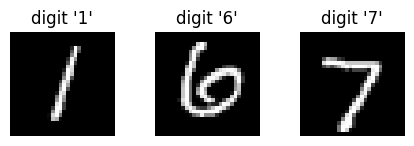

In [9]:
ANGLES = list(range(0, 360, 15))   # 24 angles: 0, 15, ..., 345
DIGITS = [1, 6, 7]


def first_of_digit(X, y, digit):
    """Return the first test image of the given digit as (1,1,28,28)."""
    idx = (y == digit).nonzero(as_tuple=True)[0][0]
    return X[idx:idx+1]


def rotate_batch(img, angles):
    """Rotate a (1,1,H,W) image by each angle. Returns (len(angles),1,H,W)."""
    return torch.stack([TF.rotate(img[0], float(a), fill=0.0) for a in angles])


images   = {d: first_of_digit(X_test, y_test, d) for d in DIGITS}
rotations = {d: rotate_batch(images[d], ANGLES) for d in DIGITS}

# Quick preview
fig, axes = plt.subplots(1, 3, figsize=(4.5, 1.5))
for ax, d in zip(axes, DIGITS):
    ax.imshow(images[d][0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"digit '{d}'"); ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Rotated Image Strips

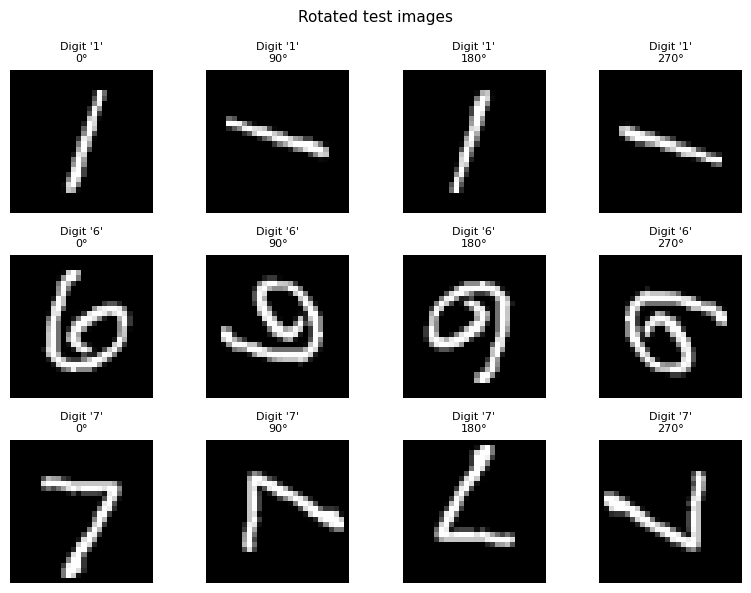

In [10]:
showcase_angles = [0, 90, 180, 270]

fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for row, d in enumerate(DIGITS):
    frames = rotate_batch(images[d], showcase_angles)
    for col, (ax, angle) in enumerate(zip(axes[row], showcase_angles)):
        ax.imshow(frames[col, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"Digit '{d}'\n{angle}\u00b0", fontsize=8)
        ax.axis('off')
plt.suptitle("Rotated test images", fontsize=11)
plt.tight_layout()
plt.show()

## Helper Functions for Uncertainty Scoring

In [11]:
@torch.no_grad()
def compute_log_density(model, X, batch_size=512):
    """Compute KDM input log-likelihood log P(x) for each sample."""
    model.eval()
    dev = next(model.parameters()).device
    scores = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(dev)
        rho_x = pure2dm(model.encoder(xb))
        scores.append(model.kdm.log_marginal(rho_x))
    return torch.cat(scores).cpu().numpy()


@torch.no_grad()
def compute_neg_logp(model, X, batch_size=512):
    """OOD score: -log P(x). Higher values indicate more OOD inputs."""
    return -compute_log_density(model, X, batch_size)


@torch.no_grad()
def compute_entropy_ood_score(model, X, batch_size=512, is_logit=False):
    """OOD score: Shannon entropy H(p) of the predicted class distribution."""
    model.eval()
    dev = next(model.parameters()).device
    scores = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(dev)
        out = model(xb)
        probs = F.softmax(out, dim=1) if is_logit else out
        entropy = -(probs * torch.log(probs.clamp_min(1e-12))).sum(dim=1)
        scores.append(entropy)
    return torch.cat(scores).cpu().numpy()


@torch.no_grad()
def compute_msp_ood_score(model, X, batch_size=512, is_logit=False):
    """OOD score: 1 - max probability (MSP, Hendrycks & Gimpel 2017)."""
    model.eval()
    dev = next(model.parameters()).device
    scores = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(dev)
        out = model(xb)
        probs = F.softmax(out, dim=1) if is_logit else out
        scores.append(1.0 - probs.max(dim=1).values)
    return torch.cat(scores).cpu().numpy()

## 9. Calibrating OOD Thresholds on In-Distribution Data

Before examining rotation curves, we calibrate a detection threshold for each
uncertainty measure using the full MNIST test set as a proxy for in-distribution data.

For each measure we set the threshold at the **95th percentile** of the scores on
in-distribution samples. This corresponds to a **5% false positive rate**: only 5%
of normal test images would be incorrectly flagged as anomalous.

- For **−log P(x)**: higher score = further from training density; the threshold is the
  95th percentile of in-distribution −log P(x) scores, equivalent to the **5th
  percentile of log P(x)** (the convention used in the original notebook).
- For **entropy** and **1 − MSP**: higher score = more uncertain; the threshold is the
  95th percentile of in-distribution scores.

These threshold lines are shown as dashed red horizontal lines in the rotation plots
below, providing an interpretable reference: rotation angles where the curve rises above
the threshold are those that would be flagged as out-of-distribution.

In-distribution thresholds (5% FPR):
  -log P(x) : 97.549  (= log P(x) 5th pct: -97.549)
  Entropy   : 0.003
  1 - MSP   : 0.000


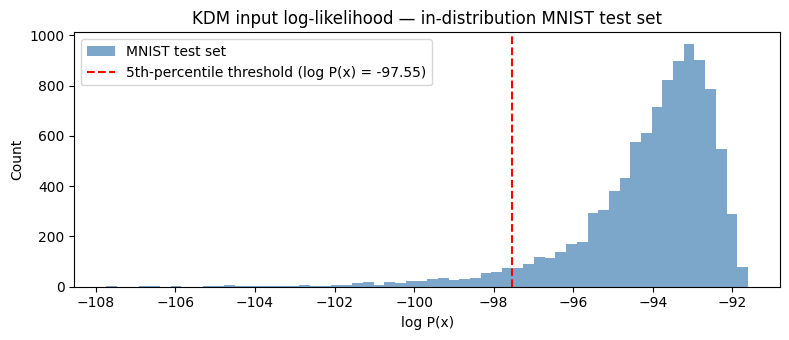

In [12]:
# Compute all three OOD scores on the in-distribution test set
test_neg_logp  = compute_neg_logp(kdm_model, X_test)
test_entropy   = compute_entropy_ood_score(kdm_model, X_test, is_logit=False)
test_msp       = compute_msp_ood_score(kdm_model, X_test, is_logit=False)

# 5% FPR threshold = 95th percentile of in-distribution OOD score
thresh_neg_logp = np.percentile(test_neg_logp, 95)
thresh_entropy  = np.percentile(test_entropy,  95)
thresh_msp      = np.percentile(test_msp,      95)

print(f"In-distribution thresholds (5% FPR):")
print(f"  -log P(x) : {thresh_neg_logp:.3f}  (= log P(x) 5th pct: {-thresh_neg_logp:.3f})")
print(f"  Entropy   : {thresh_entropy:.3f}")
print(f"  1 - MSP   : {thresh_msp:.3f}")

# Visualise the log P(x) distribution with threshold
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(-test_neg_logp, bins=60, color='steelblue', alpha=0.7, label='MNIST test set')
ax.axvline(-thresh_neg_logp, color='red', linestyle='--',
           label=f'5th-percentile threshold (log P(x) = {-thresh_neg_logp:.2f})')
ax.set_xlabel('log P(x)')
ax.set_ylabel('Count')
ax.set_title('KDM input log-likelihood \u2014 in-distribution MNIST test set')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Individual Uncertainty Diagrams per Measure and Digit

We now compare the three uncertainty measures — **Shannon entropy**, **1 − MSP**, and
**−log P(x)** — across all three digits as a function of rotation angle.

**Why compare these three measures?**

Entropy and 1 − MSP capture **label-level** uncertainty: they measure how spread or
concentrated the predicted class distribution is. They answer the question *"is the
model unsure which class to assign?"*

In contrast, −log P(x) captures **input-level** novelty: it measures how well the
input fits the density learned by the KDM over the training distribution. It answers
the question *"has the model seen inputs like this before?"*

These two types of uncertainty can diverge. A rotated digit may still be confidently
classified into some class (low entropy, low 1 − MSP) while being far from any
training prototype (high −log P(x)). This is precisely the overconfidence failure
that softmax classifiers exhibit: the softmax output depends only on the *direction*
of the latent vector, not on its distance from training data, so a model can be
maximally confident about a wrong or distorted input.

Each panel shows the measure for one digit across the full rotation sweep. The dashed
red line marks the 5% FPR threshold calibrated in Section 9.

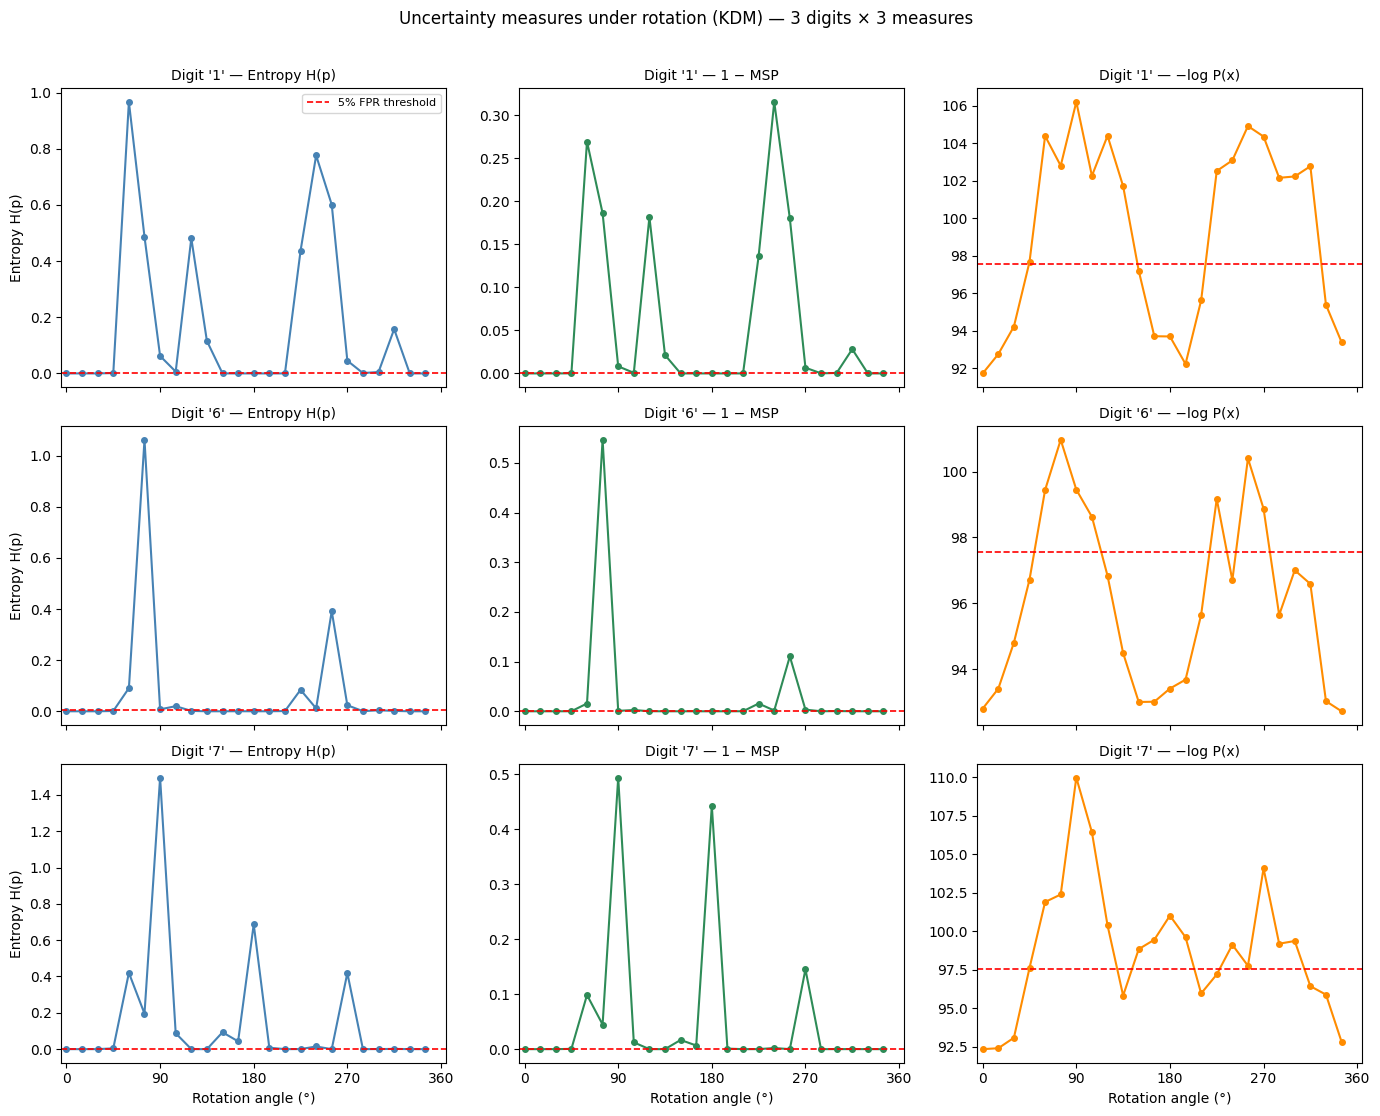

In [13]:
dev = next(kdm_model.parameters()).device

# Pre-compute all scores for each digit
scores_by_digit = {}
for d in DIGITS:
    X_rot = rotations[d].to(dev)
    scores_by_digit[d] = {
        'entropy':   compute_entropy_ood_score(kdm_model, X_rot, is_logit=False),
        'msp':       compute_msp_ood_score(kdm_model, X_rot, is_logit=False),
        'neg_logp':  compute_neg_logp(kdm_model, X_rot),
    }

measure_cfg = [
    ('entropy',  'Entropy H(p)',    thresh_entropy,  'steelblue'),
    ('msp',      '1 \u2212 MSP',   thresh_msp,      'seagreen'),
    ('neg_logp', '\u2212log P(x)', thresh_neg_logp, 'darkorange'),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for row, d in enumerate(DIGITS):
    for col, (key, label, thresh, color) in enumerate(measure_cfg):
        ax = axes[row, col]
        scores = scores_by_digit[d][key]
        ax.plot(ANGLES, scores, color=color, marker='o', ms=4, linewidth=1.5)
        ax.axhline(thresh, color='red', linestyle='--', linewidth=1.2,
                   label='5% FPR threshold')
        ax.set_title(f"Digit '{d}' \u2014 {label}", fontsize=10)
        ax.set_xticks(range(0, 361, 90))
        ax.set_xlim(-5, 365)
        if row == 2:
            ax.set_xlabel('Rotation angle (\u00b0)')
        if col == 0:
            ax.set_ylabel(label)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

plt.suptitle('Uncertainty measures under rotation (KDM) \u2014 3 digits \u00d7 3 measures',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# Compute full probability arrays for all rotations — needed for heatmaps.
# We gather P(class | rotated image) for both KDM and MLP baseline.

@torch.no_grad()
def predict_probs(model, X, batch_size=512, is_logit=False):
    """Return (N, 10) probability array for a batch of images."""
    model.eval()
    dev = next(model.parameters()).device
    out_list = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(dev)
        out = model(xb)
        probs = F.softmax(out, dim=1) if is_logit else out
        out_list.append(probs.cpu().numpy())
    return np.concatenate(out_list, axis=0)


kdm_probs   = {d: predict_probs(kdm_model,      rotations[d], is_logit=False) for d in DIGITS}
base_probs  = {d: predict_probs(baseline_model, rotations[d], is_logit=True)  for d in DIGITS}

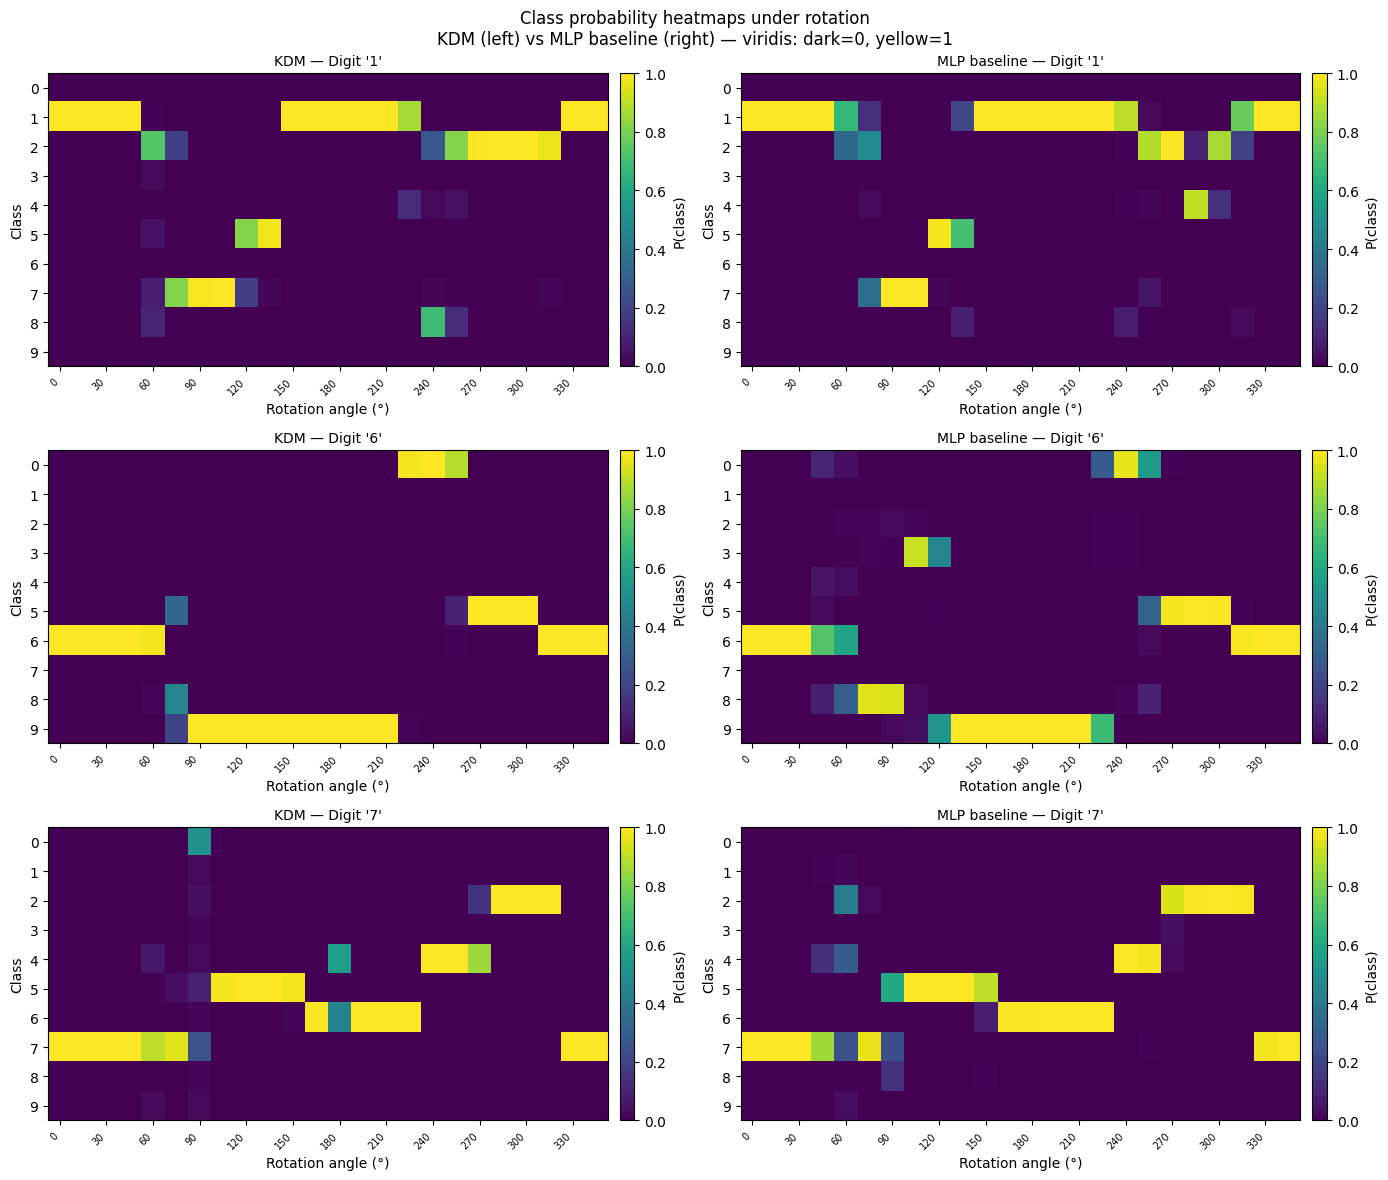

In [15]:
# Probability heatmaps: rows = class (0-9), columns = rotation angle.
# Left column: KDM; right column: MLP baseline.
# The KDM is expected to show gradual teal transitions where the baseline
# shows hard yellow blocks — reflecting the difference in how each model
# responds when the input moves away from the training distribution.

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, d in enumerate(DIGITS):
    for col, (probs, model_label) in enumerate([
        (kdm_probs[d],  'KDM'),
        (base_probs[d], 'MLP baseline'),
    ]):
        ax = axes[row, col]
        # probs: (n_angles, 10) -> transpose so rows=class, cols=angle
        im = ax.imshow(probs.T, aspect='auto', interpolation='nearest',
                       cmap='viridis', vmin=0, vmax=1, origin='upper')
        ax.set_yticks(range(10))
        ax.set_yticklabels([str(c) for c in range(10)])
        ax.set_xticks(range(0, len(ANGLES), 2))
        ax.set_xticklabels([str(ANGLES[i]) for i in range(0, len(ANGLES), 2)],
                           rotation=45, ha='right', fontsize=7)
        ax.set_xlabel('Rotation angle (\u00b0)')
        ax.set_ylabel('Class')
        ax.set_title(f"{model_label} \u2014 Digit '{d}'", fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='P(class)')

plt.suptitle(
    'Class probability heatmaps under rotation\n'
    'KDM (left) vs MLP baseline (right) \u2014 viridis: dark=0, yellow=1',
    fontsize=12
)
plt.tight_layout()
plt.show()

## 11. Joint Entropy and −log P(x) Diagrams

The individual plots in Section 10 show each measure separately. Here we overlay
**entropy** and **−log P(x)** on a shared rotation axis using dual y-axes, one panel
per digit.

This joint view is designed to reveal when the two measures are **aligned** —
both rising together as the digit becomes geometrically distorted — versus when they
**diverge**. Divergence is theoretically possible because entropy captures label-level
uncertainty while −log P(x) captures input-level novelty:

- If the model remains *confident about a (possibly wrong) class* while the input moves
  far from training prototypes, entropy stays low while −log P(x) rises. This is the
  overconfidence failure that motivates the KDM's input density score.
- If the model becomes *uncertain across labels* precisely because kernel weights have
  decayed, both measures rise together — the KDM's intrinsic calibration mechanism.

Dashed lines mark the 5% FPR thresholds for each measure on their respective axes.

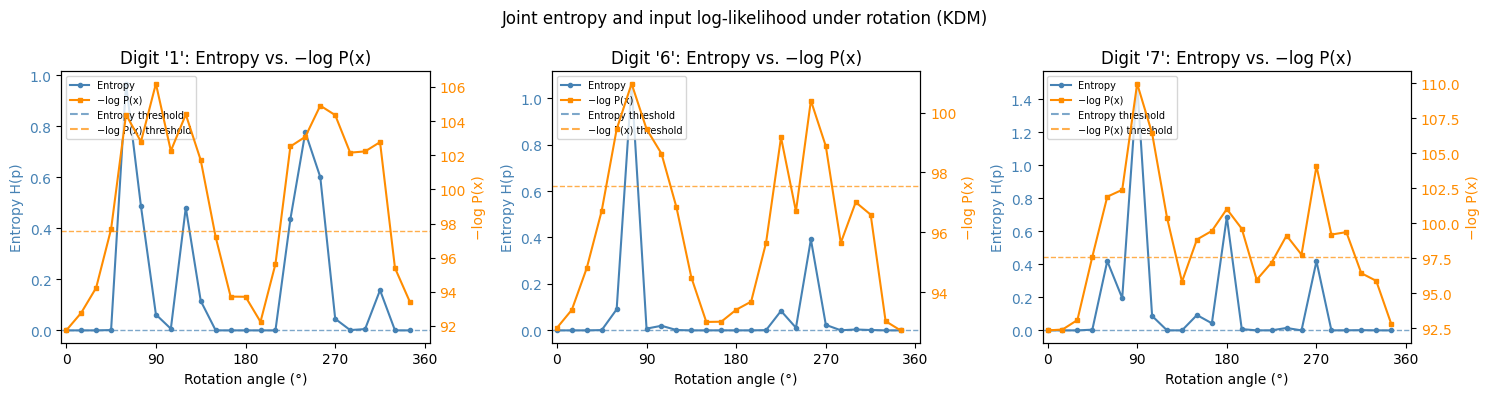

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, d in zip(axes, DIGITS):
    entropy_scores  = scores_by_digit[d]['entropy']
    neg_logp_scores = scores_by_digit[d]['neg_logp']

    ax2 = ax.twinx()

    l1, = ax.plot(ANGLES, entropy_scores, color='steelblue', marker='o', ms=3,
                  linewidth=1.5, label='Entropy H(p)')
    ax.axhline(thresh_entropy, color='steelblue', linestyle='--', linewidth=1.0, alpha=0.7)

    l2, = ax2.plot(ANGLES, neg_logp_scores, color='darkorange', marker='s', ms=3,
                   linewidth=1.5, label='\u2212log P(x)')
    ax2.axhline(thresh_neg_logp, color='darkorange', linestyle='--', linewidth=1.0, alpha=0.7)

    ax.set_xlabel('Rotation angle (\u00b0)')
    ax.set_ylabel('Entropy H(p)', color='steelblue')
    ax2.set_ylabel('\u2212log P(x)', color='darkorange')
    ax.set_xticks(range(0, 361, 90))
    ax.set_xlim(-5, 365)
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    thresh_line_blue = Line2D([0], [0], color='steelblue', linestyle='--', alpha=0.7)
    thresh_line_oran = Line2D([0], [0], color='darkorange', linestyle='--', alpha=0.7)
    ax.legend(
        [l1, l2, thresh_line_blue, thresh_line_oran],
        ['Entropy', '\u2212log P(x)', 'Entropy threshold', '\u2212log P(x) threshold'],
        loc='upper left', fontsize=7
    )
    ax.set_title(f"Digit '{d}': Entropy vs. \u2212log P(x)")

plt.suptitle('Joint entropy and input log-likelihood under rotation (KDM)', fontsize=12)
plt.tight_layout()
plt.show()

## 12. OOD Detection — ROC Curves and AUROC

The rotation curves in Sections 10 and 11 provide a qualitative view of how each
measure responds to a specific type of distributional shift for individual images.
Here we evaluate OOD detection **quantitatively** across a held-out set.

**Experimental setup:**

- **In-distribution**: 1 000 MNIST test images sampled uniformly across all 10 classes.
- **OOD**: the same 1 000 images, each rotated by a random angle drawn uniformly from
  [45°, 315°] — angles that substantially distort the canonical digit appearance.
- **Task**: binary classification — score each image as in-distribution (label 0) or
  OOD (label 1) using the uncertainty measure as a score.

**Why ROC curves?** A ROC curve sweeps the detection threshold from strict to
lenient and plots the true positive rate (OOD correctly detected) against the false
positive rate (normal images incorrectly flagged) at each threshold. The area under
the ROC curve (AUROC) summarises performance in a single threshold-free number.

**Five OOD detection configurations** are compared:

| # | Model | Score | Signal source |
|---|---|---|---|
| 1 | KDM | −log P(x) | Input distance from learned density |
| 2 | KDM | Entropy H(p) | Label-level uncertainty |
| 3 | KDM | 1 − MSP | Label confidence |
| 4 | MLP baseline | Entropy H(p) | Label-level uncertainty (no density) |
| 5 | MLP baseline | 1 − MSP | Label confidence (no density) |

The MLP baseline uses the same CNN encoder as the KDM. Any difference in OOD
detection performance therefore stems from the classifier head itself: the KDM's
kernel-based output naturally provides an input density estimate, while the softmax
head has no such mechanism and can only rely on label-level signals.

Method                  AUROC
--------------------------------
KDM  −log P(x)  0.9483
KDM  Entropy     0.9332
KDM  1−MSP   0.9273
MLP  Entropy     0.9299
MLP  1−MSP   0.9291


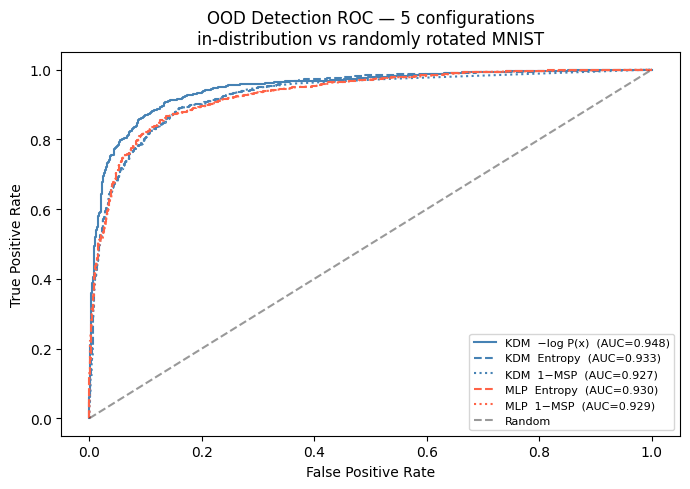

In [17]:
N_OOD   = 1000
rng_ood = np.random.RandomState(0)
ood_idx = rng_ood.choice(len(X_test), size=N_OOD, replace=False)
X_in    = X_test[ood_idx]

ood_angles = rng_ood.uniform(45, 315, size=N_OOD)
X_ood = torch.stack([
    TF.rotate(X_in[i], float(ood_angles[i]), fill=0.0)
    for i in range(N_OOD)
])

X_eval = torch.cat([X_in, X_ood], dim=0)
y_true  = np.array([0] * N_OOD + [1] * N_OOD)   # 0 = in-dist, 1 = OOD

# Compute all 5 OOD scores
ood_scores = {
    'KDM  \u2212log P(x)': compute_neg_logp(kdm_model, X_eval),
    'KDM  Entropy   ':     compute_entropy_ood_score(kdm_model,      X_eval, is_logit=False),
    'KDM  1\u2212MSP ':    compute_msp_ood_score(kdm_model,          X_eval, is_logit=False),
    'MLP  Entropy   ':     compute_entropy_ood_score(baseline_model, X_eval, is_logit=True),
    'MLP  1\u2212MSP ':    compute_msp_ood_score(baseline_model,     X_eval, is_logit=True),
}

aurocs = {name: roc_auc_score(y_true, s) for name, s in ood_scores.items()}

print(f"{'Method':<22}  AUROC")
print("-" * 32)
for name, auc in aurocs.items():
    print(f"{name}  {auc:.4f}")

# KDM = blue family, Baseline = red family
styles = [
    ('KDM  \u2212log P(x)', 'steelblue', '-'),
    ('KDM  Entropy   ',     'steelblue', '--'),
    ('KDM  1\u2212MSP ',    'steelblue', ':'),
    ('MLP  Entropy   ',     'tomato',    '--'),
    ('MLP  1\u2212MSP ',    'tomato',    ':'),
]

plt.figure(figsize=(7, 5))
for name, color, ls in styles:
    fpr, tpr, _ = roc_curve(y_true, ood_scores[name])
    plt.plot(fpr, tpr, color=color, linestyle=ls,
             label=f"{name.strip()}  (AUC={aurocs[name]:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('OOD Detection ROC \u2014 5 configurations\nin-distribution vs randomly rotated MNIST')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()